In [1]:
import pandas as pd
import pathlib
import rootutils
import torch
import tqdm
import numpy as np
import seaborn as sns

rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
root = pathlib.Path(rootutils.find_root("."))

from torch.nn import functional as F
from matplotlib import pyplot as plt

from src.core.data.sounding_out_chorus import SoundingOutChorus
from src.core.transforms.translation import translation_1d as translation
from src.core.models.sivae import SIVAE
from src.core.models.vae import VAE

base_path = pathlib.Path("/its/home/kag25/experiments/v3/translation_idx/")
df1 = pd.read_parquet(base_path / "majestic-lesson/metrics.parquet")
df1["translation_idx"] = 0
df2 = pd.read_parquet(base_path / "varied-serpent/metrics.parquet")
df2["translation_idx"] = 1
df3 = pd.read_parquet(base_path / "small-enrico/metrics.parquet")
df3["translation_idx"] = 2
df4 = pd.read_parquet(base_path / "welcome-college/metrics.parquet")
df4["translation_idx"] = 3
df5 = pd.read_parquet(base_path / "vivid-asia/metrics.parquet")
df5["translation_idx"] = 4
df = pd.concat([df1, df2, df3, df4, df5])

# df1 = pd.read_parquet(base_path / "test/majestic-lesson/features.parquet")
# df1["model_name"] = "majestic-lesson

# df2 = pd.read_parquet(base_path / "test/varied-serpent/features.parquet")
# df2["model_name"] = "varied-serpent

/its/home/kag25/projects/ecolistening/interpretable_bioacoustic_classifiers/.venv/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


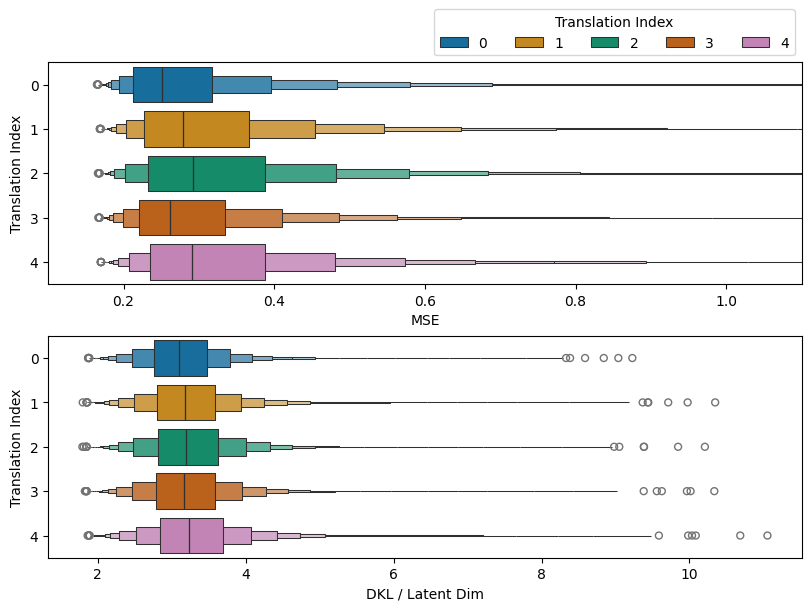

In [20]:
palette = sns.color_palette("colorblind", n_colors=5)

fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(8, 6), constrained_layout=True)
sns.boxenplot(data=df, x="mse", y="translation_idx", hue="translation_idx", palette=palette, orient="h", ax=ax1, legend=True)
ax1.set_xlabel("MSE")
ax1.set_ylabel("Translation Index")
ax1.set_xlim(0.1, 1.1)
sns.move_legend(ax1, "lower right", bbox_to_anchor=(1, 1), ncol=5, title="Translation Index")
sns.boxenplot(data=df, x="dkl_norm", y="translation_idx", hue="translation_idx", palette=palette, orient="h", ax=ax2, legend=False)
ax2.set_xlabel("DKL / Latent Dim")
ax2.set_ylabel("Translation Index")
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


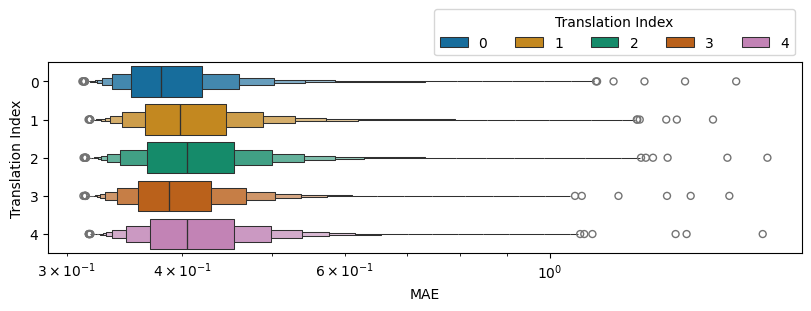

In [17]:
palette = sns.color_palette("colorblind", n_colors=5)

fig, ax1 = plt.subplots(figsize=(8, 3), constrained_layout=True)
sns.boxenplot(data=df, x="mae", y="translation_idx", hue="translation_idx", palette=palette, orient="h", ax=ax1, legend=True)
ax1.set_xlabel("MAE")
ax1.set_ylabel("Translation Index")
ax1.set_xscale("log")
sns.move_legend(ax1, "lower right", bbox_to_anchor=(1, 1), ncol=5, title="Translation Index")
plt.show()

First takeaways:

1. Difference looks pretty negligible.
1. DKL and MSE are higher when the translation are applied at the penultimate layer. Features are further from the prior, suggesting they contain more information and are therefore more descriptive, but the reconstruction isn't such a high quality, suggesting that there wasn't enough capacity in the last layer to effectively describe that information
2. 

Can we subset the data somehow? Translation IDX 4 requires that the prototype be preserved to the penultimate layer.

What about looking at the shift derivative for each model. Which are more / less shift invariant?